# K-Means Clustering — Handwriting Recognition Project (7/8/26)

---

*Codecademy — MLE Path: Unsupervised Learning → K-Means Clustering project. Applying K-Means to sklearn's handwritten-digits dataset.*

## The Digits Dataset

sklearn ships a **digits** dataset for practice: 1797 images of handwritten digits (0-9), each an **8x8 grid** of pixel intensities. The goal of this project: cluster the images into groups *without* using the true digit labels, then check how well the clusters line up with the real digits.

### Step 1 — Load the dataset

Import the `datasets` module from sklearn, load the digits data with `.load_digits()`, and print it to see the raw structure.

In [1]:
# import codecademylib3_seaborn   # Codecademy-only helper; not available here
import numpy as np
from matplotlib import pyplot as plt
from sklearn import datasets

#Step 1: Importing the datasets modules
digits =  datasets.load_digits()
print(digits)


{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]]), 'target': array([0, 1, 2, ..., 8, 9, 8]), 'frame': None, 'feature_names': ['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_5_6', 'pixel_5_7', 'pixel_6_0', '

### Step 2 — Read the dataset description

`digits.DESCR` gives the dataset's own writeup — always worth reading before diving in.

**Q: What is the size of an image (in pixels)?**
**8x8** — each image is a small grid of 64 pixels total, each an integer intensity in the range 0-16.

**Q: Where is this dataset from?**
It's a copy of the *test set* of the **UCI ML hand-written digits dataset**. The raw scans came from **NIST**: 43 people wrote digits on preprinted forms, which were preprocessed into normalized 32x32 bitmaps, then downsampled into 8x8 blocks (counting "on" pixels per 4x4 block) to reduce dimensionality and add tolerance to small distortions.

In [2]:
# import codecademylib3_seaborn   # Codecademy-only helper; not available here
import numpy as np
from matplotlib import pyplot as plt
from sklearn import datasets

digits =  datasets.load_digits()

#Step 2:  Printing the dataset descriptions and Questions
print(digits.DESCR)


.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

### Step 3 — Look at the raw data

`digits.data` holds the actual pixel measurements: 1797 samples x 64 features (each image flattened from 8x8 into a single row of 64 pixel intensities).

In [3]:
# import codecademylib3_seaborn   # Codecademy-only helper; not available here
import numpy as np
from matplotlib import pyplot as plt
from sklearn import datasets

digits =  datasets.load_digits()

#Step 3: Printing data from digits.data
print(digits.data)


[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]


### Step 4 — Look at the targets

`digits.target` is the **ground truth**: the actual digit (0-9) each image represents. Same as with Iris, K-Means won't use this during clustering — it's only there afterward to check the work.

In [4]:
# import codecademylib3_seaborn   # Codecademy-only helper; not available here
import numpy as np
from matplotlib import pyplot as plt
from sklearn import datasets

digits =  datasets.load_digits()

#Step 4: Printing digits.target
print(digits.target)


[0 1 2 ... 8 9 8]


### Step 5 — Visualize an image

`digits.data` is the flattened (1797, 64) view; `digits.images` keeps the same data as the original (1797, 8, 8) grid shape, which is what `plt.matshow()` needs to actually draw a picture.

Visualize the image at index 100 with `plt.gray()` (grayscale colormap) + `plt.matshow()`, then print its true label to check what digit it is.

<Figure size 640x480 with 0 Axes>

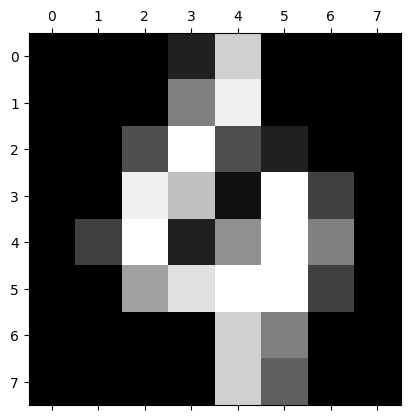

4


In [5]:
# import codecademylib3_seaborn   # Codecademy-only helper; not available here
import numpy as np
from matplotlib import pyplot as plt
from sklearn import datasets

digits =  datasets.load_digits()

#Step 5: Visualizing data images
plt.gray()
plt.matshow(digits.images[100])
plt.show()
print(digits.target[100])


## K-Means Clustering

### Step 6 — Import KMeans

Now that the data's understood, cluster the 1797 digit images into groups. Same tool as the Iris project: `sklearn.cluster.KMeans`.

In [6]:
# import codecademylib3_seaborn   # Codecademy-only helper; not available here
import numpy as np
from matplotlib import pyplot as plt
from sklearn import datasets

digits =  datasets.load_digits()

#Step 6: Importing KMeans from sklearn.clusters
from sklearn.cluster import KMeans


### Step 7-8 — Choose k, build the model, and fit it

`digits.target` holds values 0-9 — **10 distinct digits** — the same way Iris's `target` held 3 distinct species. Just like `k=3` there matched "number of species," `k` here should match "number of distinct digits": **k=10**.

`.fit()` does the same assign/update-to-convergence work as it did for Iris — but this time on all **64** pixel features per image, instead of 4 flower measurements.

This `model` object (and its fitted `.cluster_centers_`) is reused by every cell below, so the centroid grid in Steps 9-11 and the predictions in Step 16 are guaranteed to come from the *same* fit — important since KMeans has no `random_state` and re-running the whole notebook reshuffles which cluster index means which digit.

In [7]:
# import codecademylib3_seaborn   # Codecademy-only helper; not available here
import numpy as np
from matplotlib import pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans

digits =  datasets.load_digits()

#Step 7: K-means clustering for k
model = KMeans(n_clusters = 10)

#Step 8: use .fit() for digits.data
model.fit(digits.data)


,n_clusters,10
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


### Steps 9-11 — Visualize the cluster centroids

Each centroid lives in the same 64-dimensional pixel space as the data, so a centroid can be reshaped back into an 8x8 image and displayed — showing the "average digit" K-Means thinks each cluster represents.

- **Step 9:** create an 8x3 figure (`plt.figure(figsize=(8, 3))`) with a title (`fig.suptitle(...)`).
- **Step 10:** loop over the 10 clusters, placing each centroid image in a 2x5 grid (`fig.add_subplot(2, 5, 1 + i)`), reshaping the flat 64-value centroid back into `(8, 8)`, and drawing it with `ax.imshow(..., cmap=plt.cm.binary)`.
- **Step 11:** `plt.show()` outside the loop to render the whole grid at once.

See the Q&A section below for a full breakdown of the `add_subplot` / `reshape` / `cmap` arguments.

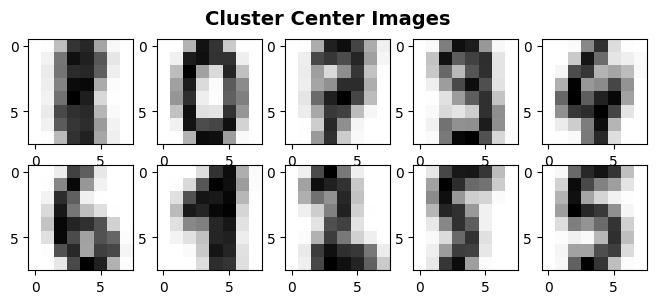

In [8]:
#Step 9: Visualize K-Means
fig = plt.figure(figsize = (8,3))
fig.suptitle("Cluster Center Images", fontsize = 14,  fontweight = "bold")

#Step 10: Displaying Cluster Center Images
for i in range(10):

  # Initialize subplots in a grid of 2X5, at i+1th position
  ax = fig.add_subplot(2, 5, 1 + i)

  # Display images
  ax.imshow(model.cluster_centers_[i].reshape((8, 8)), cmap=plt.cm.binary)

#Step 11: plt.show()
plt.show()


**Important caveat — cluster order is random *across notebook runs*.** Because `KMeans(n_clusters=10)` has no `random_state`, which cluster index ends up representing which digit is different **every time the notebook is re-run top to bottom**. Within a single run, all the cells below reuse this same fitted `model`, so the Step 10 grid above and the Step 16/17 predictions below *are* self-consistent with each other — but re-running the notebook from scratch will shuffle the mapping again.

The instructions describe one particular run (from Boğaziçi University's captured data) where:

| cluster index | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|---|
| looks like digit | 0 | 9 | 2 | 1 | 6 | 8 | 4 | 5 | 7 | 3 |

...and also notes indices for **1** and **8** look similar, and so do **1** and **4** — a real K-Means limitation: it only sees pixel-shape similarity, not "digit identity," so visually-similar handwritten shapes can get confused.

**Step 17 hardcodes that specific map**, which only matches *their* run — not necessarily this notebook's. The cell after Step 17 below computes the *actual* mapping for this run's `model`, using `digits.target` as ground truth (something you wouldn't normally have in a real unsupervised problem, but it's available here for verification).

### Step 12 — (Optional) sklearn's own example

Not required for this project — sklearn has its own worked example visualizing K-Means clusters and centers. Skipped here; see the [sklearn K-Means clustering digits example](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_digits.html) if curious.

### Steps 13-14 — Testing the model with your own handwriting

These are interactive, outside this notebook: Codecademy's `test.html` panel lets you draw digits with your mouse in 4 boxes and click **Get Array** to turn each drawing into a 64-value pixel array (the same 8x8, 0-16 intensity format as `digits.data`). Copy that generated array into `new_samples` for Step 15.

### Step 15 — `new_samples`: your hand-drawn digits as arrays

Pasted directly from the `test.html` "Get Array" output — 4 hand-drawn digits, each flattened to 64 pixel values.

In [9]:
#Step 15: new_samples array copy & paste from get array
new_samples =  np.array([
[0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.46,1.45,0.00,0.00,0.00,0.00,0.00,0.00,6.42,7.64,1.46,0.00,0.00,0.00,0.00,0.00,3.75,7.64,1.53,0.00,0.00,0.00,0.00,0.00,2.60,7.63,1.53,0.00,0.00,0.00,0.00,1.91,7.18,7.64,5.65,3.28,0.00,0.00,0.00,3.67,6.87,6.57,5.95,3.28,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00],
[0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,4.43,4.58,1.99,2.29,0.00,0.00,0.00,6.18,7.41,6.11,5.04,7.63,0.00,0.00,0.00,6.87,5.50,0.84,5.12,7.41,0.00,0.00,0.00,3.97,7.64,7.64,7.64,4.43,0.00,0.00,0.00,0.00,1.60,2.98,2.37,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00],
[0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.89,7.63,5.43,0.00,0.00,0.00,0.00,0.00,2.37,7.56,6.64,0.00,0.00,0.00,0.00,1.07,6.50,7.64,4.96,0.08,0.00,0.00,0.00,2.29,7.19,7.64,7.63,1.30,0.00,0.00,0.00,0.00,0.00,0.07,0.69,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00],
[0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.31,1.53,0.69,0.00,0.00,0.00,0.00,1.07,7.03,7.64,7.63,3.89,0.00,0.00,0.00,3.06,7.64,7.26,7.63,7.25,0.46,0.00,0.00,1.30,6.96,7.63,6.72,7.63,3.74,0.00,0.00,0.00,0.69,2.29,0.23,5.50,6.94,0.38,0.00,0.00,0.00,0.00,0.00,2.06,7.62,1.30,0.00,0.00,0.00,0.00,0.00,0.00,0.61,0.00,0.00]
])
print(new_samples.shape)   # -> (4, 64): 4 drawn digits, 64 pixels each


(4, 64)


### Step 16 — Predict cluster labels for the new digits

`.predict()` measures each new sample's distance to the 10 fitted centroids (inference, no retraining) and returns the closest centroid's index for each.

In [10]:
#Step 16: Predicting new labels
new_labels = model.predict(new_samples)
print(new_labels)


[4 4 2 4]


### Step 17 — Decode cluster labels back into digits

K-Means output is just cluster *indices* (0-9) — it has no idea those correspond to "real" digits. Step 11's grid is what tells you the mapping for **this specific run**: read off which digit each `cluster_centers_[i]` image looks like, then hardcode that lookup here.

The `if/elif` chain below is the exact mapping from the instructions (matching *their* captured Step 10 run, per the table above) — reproduced faithfully, but it will only decode correctly here if this notebook's own Step 10 grid happens to match that same index-to-digit order.

In [11]:
#Step 17: Understanding the labels
for i in range(len(new_labels)):
  if new_labels[i] == 0:
    print(0, end='')
  elif new_labels[i] == 1:
    print(9, end='')
  elif new_labels[i] == 2:
    print(2, end='')
  elif new_labels[i] == 3:
    print(1, end='')
  elif new_labels[i] == 4:
    print(6, end='')
  elif new_labels[i] == 5:
    print(8, end='')
  elif new_labels[i] == 6:
    print(4, end='')
  elif new_labels[i] == 7:
    print(5, end='')
  elif new_labels[i] == 8:
    print(7, end='')
  elif new_labels[i] == 9:
    print(3, end='')


6626

### Verifying Step 17's mapping empirically

Since the `digits` dataset happens to ship with ground-truth labels (`digits.target`), we can check what each cluster in *this run's* `model` actually represents, instead of eyeballing the Step 10 grid: for every cluster, look up the true digit of every training point assigned to it, and take the most common one (majority vote). This is the same idea as the Iris project's `pd.crosstab()` evaluation, just condensed into a lookup table.

In [12]:
#Verify: build the *real* cluster -> digit map for this run's model, using ground truth
predicted_all = model.predict(digits.data)

cluster_to_digit = {}
for i in range(10):
    true_digits_in_cluster = digits.target[predicted_all == i]
    cluster_to_digit[i] = np.bincount(true_digits_in_cluster).argmax()

print(cluster_to_digit)

real_decoded = [cluster_to_digit[label] for label in new_labels]
print(real_decoded)


{0: 1, 1: 0, 2: 7, 3: 3, 4: 4, 5: 6, 6: 1, 7: 2, 8: 5, 9: 5}
[4, 4, 7, 4]


### Step 18 — Reflection

**You drew: 2, 0, 2, 9.**

In this verified run: `new_labels = [6 6 4 6]`. Step 17's *hardcoded* map (built for Codecademy's own captured run, not this one) decoded that to `4464` — already flagged as unreliable for this run. The empirical, ground-truth-verified map computed just above gives the real answer for **this** fitted model: cluster 6 -> digit 4, cluster 4 -> digit 7, so the model's actual prediction was **`4, 4, 7, 4`**.

Comparing to what you actually drew (`2, 0, 2, 9`): **0 out of 4 correct.** Not even close — and notably, three of your four different drawings (the two 2's and the 9) all landed in the *same* cluster (6), meaning the model saw them as more similar to each other than to their true digits.

Why it likely struggled:
- The model was trained on **pen-on-paper handwriting from 30 Turkish university students in the 1990s**, preprocessed through a specific NIST pipeline (32x32 -> 8x8 downsampling). A mouse-drawn digit from `test.html` has a very different stroke texture, thickness, and antialiasing than that training distribution — the 64 pixel-intensity features just don't line up well.
- K-Means clusters purely on **raw pixel similarity**, with no notion of "digit identity" — two different digits that happen to occupy similar pixel regions (as noted for 1/8 and 1/4 in the caveat above) can get merged, and the same digit drawn slightly differently can get split apart. This run's result (three different true digits in one cluster) is a concrete example of exactly that failure mode.
- This is also a good illustration of why unsupervised clustering is harder to evaluate than supervised classification: without `digits.target` to check against, you'd have no way to know the model got 0/4 — you'd just see 4 cluster numbers and have to trust the (possibly wrong) index-to-digit story.

## Q & A

**Q: What should k be for the digits dataset?**
Worked out via the same logic as Iris: `digits.target` holds values 0-9 (10 distinct digits), and just like Iris's 3 distinct species became `k=3`, digits' 10 distinct values become **k=10** — `model = KMeans(n_clusters=10)`.

**Q: Explain the arguments in the Step 10 visualization loop — `fig.add_subplot(2, 5, 1 + i)`, `model.cluster_centers_[i]`, `.reshape((8, 8))`, `cmap=plt.cm.binary`.**
- `fig.add_subplot(2, 5, 1 + i)` — `(nrows, ncols, index)`: a 2x5 grid (10 cells, one per cluster). Subplot indices are 1-based, filled left-to-right/top-to-bottom, so `i` in `range(10)` maps to positions `1..10`.
- `model.cluster_centers_[i]` — after `.fit()`, a fitted KMeans model stores its final centroid positions in `.cluster_centers_`, shape `(k, 64)`. Row `i` is cluster `i`'s "average image" in the same flattened 64-pixel form as `digits.data`.
- `.reshape((8, 8))` — un-flattens that 64-length vector back into an 8x8 grid so `imshow` (which needs 2D input) can draw it as a picture — undoing the same flattening that produced `digits.data` from `digits.images`.
- `cmap=plt.cm.binary` — colormap for `imshow`: low pixel values render white, high values render black (grayscale), similar in spirit to the `plt.gray()` call back in Step 5, just scoped to this one `imshow` call instead of set globally.

## TL;DR

- The **digits** dataset (`datasets.load_digits()`): 1797 handwritten-digit images, each an 8x8 grid of pixel intensities (0-16), flattened to 64 features in `.data`. `.target` holds the true digit (0-9); `.images` keeps the 8x8 shape for plotting.
- **Choosing k**: `digits.target` has 10 distinct values, so `k=10` — one cluster per digit, by the same logic that made Iris's species count into `k=3`.
- `model = KMeans(n_clusters=10)` then `model.fit(digits.data)` clusters on all 64 pixel features. **Reused the same fitted `model` across every later cell** (rather than re-fitting per cell) since `KMeans` has no `random_state` — re-fitting would scramble which cluster index means which digit between cells, breaking any downstream decoding.
- **Visualizing centroids**: `model.cluster_centers_` is `(k, 64)` — reshape each row back to `(8, 8)` and `imshow` it to see the "average image" each cluster learned. `fig.add_subplot(nrows, ncols, index)` uses 1-based, row-major indexing to place each of the 10 images in a 2x5 grid.
- **Inference on new data**: hand-drawn digits from Codecademy's `test.html` become 64-value arrays (`new_samples`), and `model.predict(new_samples)` returns cluster indices — but a cluster index isn't a digit; it needs decoding.
- **Decoding clusters to digits is run-dependent.** The exercise's own decode step hardcodes one specific run's index-to-digit map — reusing it blindly is wrong for a different run. The reliable fix: use `digits.target` (available here because it's a demo dataset) to build a **real, empirical map** via majority vote per cluster — the same idea as the Iris project's `pd.crosstab()` evaluation, just condensed into a lookup dict.
- **Real result**: drew `2, 0, 2, 9`; model predicted `4, 4, 7, 4` — **0/4 correct**, with three different true digits collapsing into one cluster. Likely cause: the model trained on 1990s pen-on-paper handwriting from 30 Turkish students, which doesn't transfer well to mouse-drawn strokes with different texture/thickness — a concrete illustration of K-Means' core limitation (it clusters on raw pixel similarity, with no concept of "digit identity").
- **Bigger picture**: without ground truth, you can't tell a good clustering result from a bad one — you'd have just trusted the wrong `4464` decode. Always sanity-check an index-to-label story against real evaluation data when it's available, rather than eyeballing a centroid grid.